In [39]:
# ============================================================
# Customer Churn Prediction
# Notebook 02 - Data Preparation
# ============================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [40]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("../data/processed/clean_telco_churn.csv")

print("Dataset loaded successfully.")
print(f"Shape : {df.shape}")

Dataset loaded successfully.
Shape : (7032, 21)


### Business Problem 1
#### What percentage of customers churn?

In [41]:
# ============================================================
# Customer Churn Distribution
# ============================================================

churn_summary = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customers")
)

churn_summary["Percentage"] = (
    churn_summary["Customers"] / churn_summary["Customers"].sum() * 100
).round(2)

display(churn_summary)

,Churn,Customers,Percentage
0,No,5163,73.42
1,Yes,1869,26.58


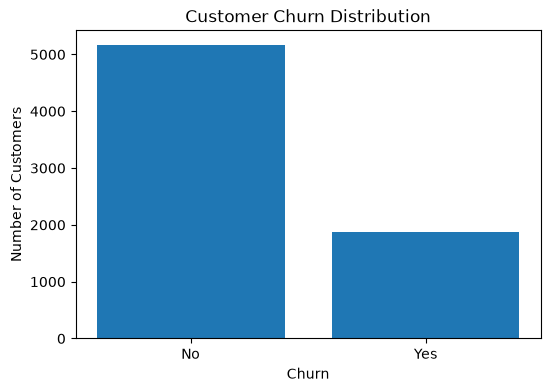

In [42]:
# ============================================================
# Churn Distribution
# ============================================================

plt.figure(figsize=(6,4))

counts = df["Churn"].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business Problem 2
#### Does contract type influence customer churn?

In [43]:
# ============================================================
# Churn by Contract Type
# ============================================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.round(2)

display(contract_churn)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


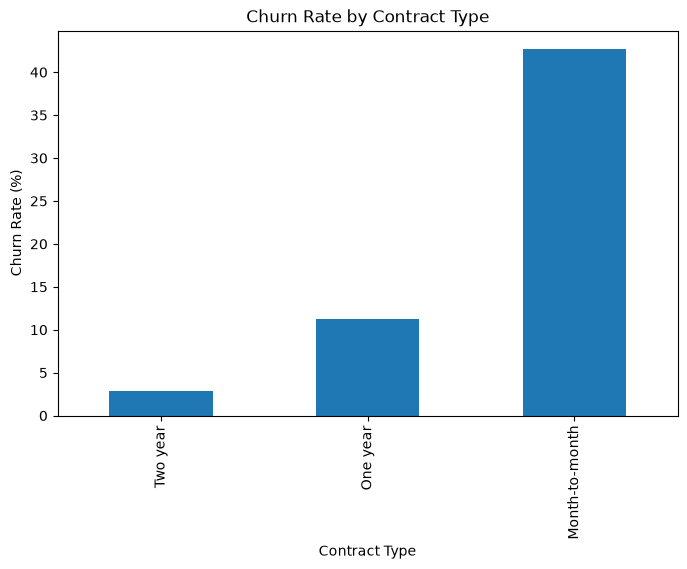

In [44]:
# ============================================================
# Churn Percentage by Contract Type
# ============================================================

(contract_churn["Yes"]).sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Insight
- Month-to-month customers have the highest churn rate.
- Two-year contract customers have the lowest churn rate.
- Churn decreases significantly as contract duration increases.

This indicates a strong relationship between contract commitment and customer retention.



#### Business Recommendation
- Identify high-risk month-to-month customers using the churn model.
- Offer incentives to upgrade to longer-term contracts.
- Improve onboarding and early customer engagement during the first few months.
- Provide personalized retention offers before renewal periods.

### Business Problem 3
#### Do customers with longer tenure churn less?

In [45]:
# ============================================================
# Average Tenure by Churn
# ============================================================

tenure_summary = (
    df.groupby("Churn")["tenure"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)

display(tenure_summary)

,mean,median,min,max
Churn,,,,
No,37.65,38.0,1,72
Yes,17.98,10.0,1,72


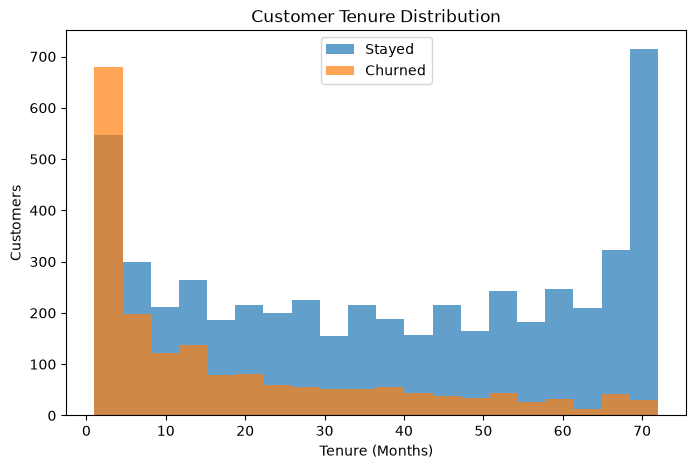

In [46]:
# ============================================================
# Tenure Distribution by Churn
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df[df["Churn"] == "No"]["tenure"],
         bins=20,
         alpha=0.7,
         label="Stayed")

plt.hist(df[df["Churn"] == "Yes"]["tenure"],
         bins=20,
         alpha=0.7,
         label="Churned")

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")
plt.legend()

plt.show()

#### Business Recommendation
- Design a strong onboarding program for new customers.
- Monitor customer activity during the first year.
- Resolve issues quickly for recently acquired customers.
- Encourage engagement with value-added features.
- Offer suitable long-term contract options after customers have experienced the service.

### Business Problem 4
#### Do customers with higher monthly charges churn more often?

In [47]:
# ============================================================
# Monthly Charges by Churn
# ============================================================

monthly_summary = (
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)

display(monthly_summary)

,mean,median,min,max
Churn,,,,
No,61.31,64.45,18.25,118.75
Yes,74.44,79.65,18.85,118.35


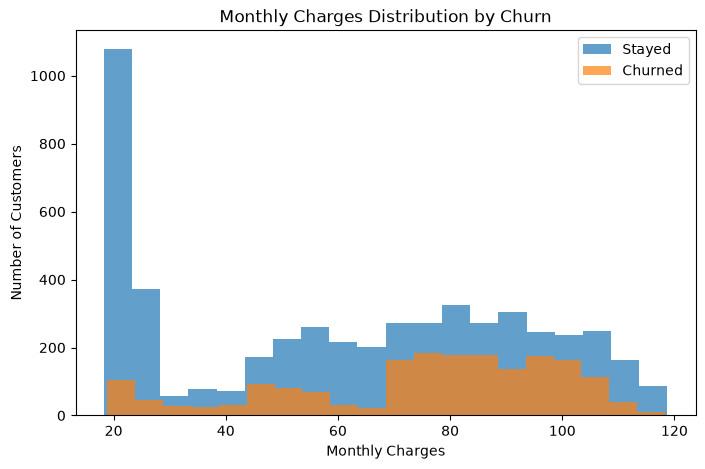

In [48]:
# ============================================================
# Monthly Charges Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn"] == "No"]["MonthlyCharges"],
    bins=20,
    alpha=0.7,
    label="Stayed"
)

plt.hist(
    df[df["Churn"] == "Yes"]["MonthlyCharges"],
    bins=20,
    alpha=0.7,
    label="Churned"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

#### Business Recommendation

If I were the Pricing Manager, I would not immediately lower prices.

Instead, I would:

- Identify which high-price customer segments churn the most.
- Review whether premium plans provide enough value for their price.
- Offer loyalty rewards or bundled discounts for high-value customers.
- Gather feedback from high-paying customers to understand dissatisfaction before changing pricing.

The goal is to improve the value proposition, not just reduce prices.

### Does Tech Support reduce customer churn?

In [49]:
# ============================================================
# Churn by Tech Support
# ============================================================

tech_support_churn = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(tech_support_churn)

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


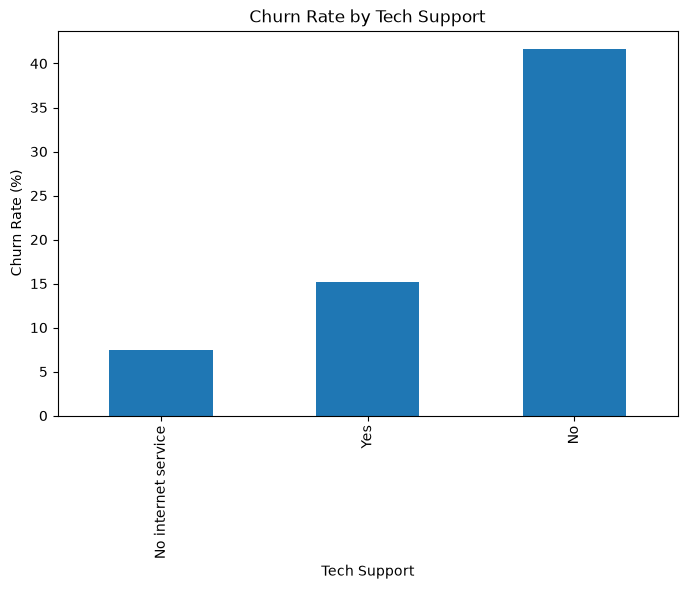

In [50]:
# ============================================================
# Churn Rate by Tech Support
# ============================================================

tech_support_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Business Insight

The data suggests that customer support plays an important role in customer retention.

Customers without Tech Support appear much more likely to leave, indicating that timely assistance and issue resolution may improve customer loyalty.

#### Business Recommendation

If I were the Head of Customer Success, I would:

- Proactively promote Tech Support to eligible customers.
- Identify customers without Tech Support who are at high risk of churn.
- Encourage adoption through free trials or bundled plans.
- Monitor support satisfaction to ensure the service delivers real value.

### Business Problem 6
#### Which services are associated with the highest customer churn?

In [51]:
# ============================================================
# Churn Rate by Service Features (Clean Summary)
# ============================================================

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

summary = []

for feature in service_columns:

    temp = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    ).round(2)

    temp = temp.reset_index()

    # Rename first column to a common name
    temp.rename(columns={temp.columns[0]: "Category"}, inplace=True)

    temp["Feature"] = feature

    summary.append(temp)

service_summary = pd.concat(summary, ignore_index=True)

display(service_summary)

Churn,Category,No,Yes,Feature
0,No,75.00,25.00,PhoneService
1,Yes,73.25,26.75,PhoneService
2,No,74.92,25.08,MultipleLines
3,No phone service,75.00,25.00,MultipleLines
4,Yes,71.35,28.65,MultipleLines
5,DSL,81.00,19.00,InternetService
6,Fiber optic,58.11,41.89,InternetService
7,No,92.57,7.43,InternetService
8,No,58.22,41.78,OnlineSecurity
9,No internet service,92.57,7.43,OnlineSecurity


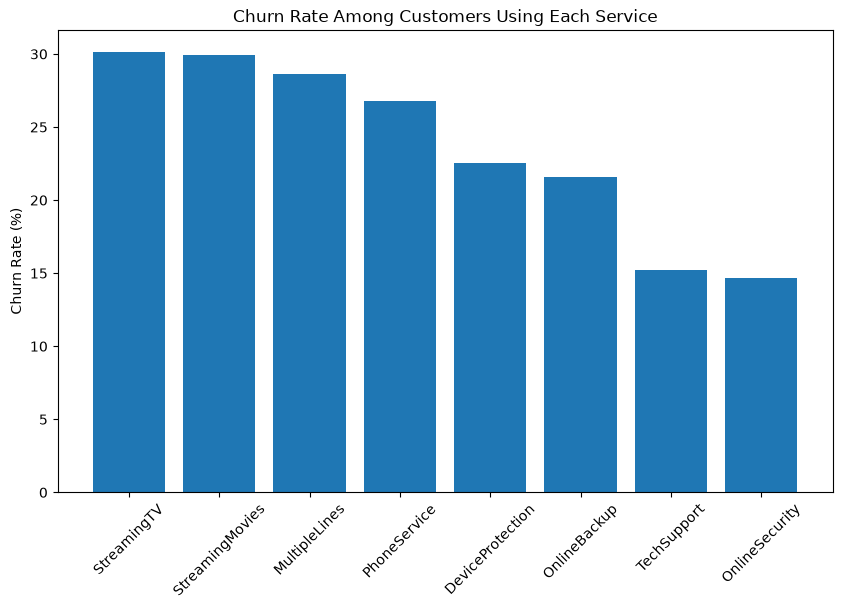

In [52]:
# ============================================================
# Churn Rate for Customers Using Each Service
# ============================================================

plot_df = service_summary[service_summary.iloc[:, 0] == "Yes"]

plot_df = plot_df.sort_values("Yes", ascending=False)

plt.figure(figsize=(10,6))

plt.bar(plot_df["Feature"], plot_df["Yes"])

plt.xticks(rotation=45)

plt.ylabel("Churn Rate (%)")

plt.title("Churn Rate Among Customers Using Each Service")

plt.show()

### Business Problem 7
#### Which customer characteristics are most associated with churn?

In [53]:
# ============================================================
# Churn Rate by Customer Characteristics
# ============================================================

business_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService",
    "Contract",
    "PaymentMethod"
]

for feature in business_features:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    summary = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    ).round(2)

    display(summary)

gender


Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


Partner


...

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


Contract


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


## Executive Summary

The strongest indicators of customer churn are month-to-month contracts, fiber optic internet service, electronic check payments, high monthly charges, and short customer tenure. In contrast, customers with long-term contracts, longer tenure, partners, dependents, and technical support exhibit substantially lower churn rates. Gender does not appear to influence customer retention.